# Testing


In [1]:
traits = [
    "aggression",
    "social",
    "greed",
    "urban",
    "mysticism"
]

In [5]:
user = {}
for t in traits:
    user[t] = 0
user

{'aggression': 0, 'social': 0, 'greed': 0, 'urban': 0, 'mysticism': 0}

In [6]:
questions = [
    {
        "question": "A tourist drops a croissant.",
        "answers": [
            {
                "id": 1,
                "text": "Strike immediately.",
                "effects": {
                    "greed": 3,
                    "aggression": 1
                }
            }
        ]
    }
]


In [10]:
user = {}
for t in traits:
    user[t] = 0
user

def apply_answer(answer: dict, user:dict):
    for chracteristic, effects in answer["effects"].items():
        user[chracteristic] += effects 
    return user



for q in questions:
    answer = next(a for a in q["answers"] if a["id"] == 1)
    user = apply_answer(answer, user)
    print(user)

{'aggression': 1, 'social': 0, 'greed': 3, 'urban': 0, 'mysticism': 0}


In [14]:
import numpy as np
import matplotlib.pyplot as plt


def plot_skills(user:dict):
    # labels and values
    labels = list(user.keys())
    values = list(user.values())

    # close the polygon
    values += values[:1]

    # angles for each axis
    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]

    # create figure
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

    # draw outline
    ax.plot(angles, values, linewidth=2)

    # fill shape
    ax.fill(angles, values, alpha=0.25)

    # labels around circle
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)

    # range
    ax.set_ylim(0, 10)

    plt.title("Pigeon Personality Profile")
    plt.show()



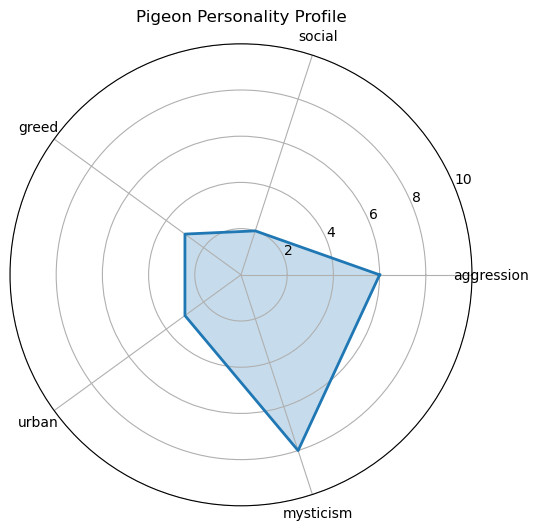

In [15]:

stats = {
    'aggression': 6,
    'social': 2,
    'greed': 3,
    'urban': 3,
    'mysticism': 8
}

plot_skills(stats)

In [16]:
import numpy as np

def classify_user(user_stats, archetypes, traits):
    """
    user_stats:
        dict like:
        {
            'aggression': 1,
            'social': 0,
            'greed': 3,
            'urban': 0,
            'mysticism': 0
        }

    archetypes:
        list of dicts:
        [
            {
                "name": "Subway Crumb Baron",
                "vector": [4,1,5,5,0]
            }
        ]

    traits:
        ordered list of trait names
    """

    # convert user dict -> vector
    user_vector = np.array([
        user_stats[t] for t in traits
    ])

    best_name = None
    best_score = -1

    for archetype in archetypes:

        archetype_vector = np.array(
            archetype["vector"]
        )

        # cosine similarity
        score = np.dot(
            user_vector,
            archetype_vector
        ) / (
            np.linalg.norm(user_vector)
            * np.linalg.norm(archetype_vector)
        )

        if score > best_score:
            best_score = score
            best_name = archetype["name"]

    return best_name

In [18]:
traits = [
    "aggression",
    "social",
    "greed",
    "urban",
    "mysticism"
]

archetypes = [
    {
        "name": "Subway Crumb Baron",
        "vector": [4,1,5,5,0]
    },
    {
        "name": "Cathedral Oracle",
        "vector": [0,2,1,2,5]
    }
]

user_stats = {
    'aggression': 1,
    'social': 0,
    'greed': 3,
    'urban': 0,
    'mysticism': 0
}

result = classify_user(
    user,
    archetypes,
    traits
)

print(result)

Subway Crumb Baron
